# Customising Spirals with a GUI

There are dozens of parameters to fiddle with in customising these colliding wind nebulae, from the orbit to the stellar winds to the image quality. Because of this, it can be especially tedious to have to re-run a python script or notebook every time you make a change to see how it affects the nebula. Worry not, for xenomorph comes shipped with a basic tkinter graphical user interface!

In [5]:
import sys; sys.path.append('../..')    # ignore this! just needed since this file is away from the xenomorph root dir

# start off by importing the relevant modules
import xenomorph as xm
import xenomorph.geometry as gm
import xenomorph.systems as wrb

Initialising the GUI is as easy as this:

In [ ]:
xm.gui.create_GUI()

Running the above creates a popup window with the tkinter graphical user interface, which should look like this:

<img src="assets/gui-basic.png" alt="GUI Basic" width="600"/>

The default model is of the archetypical pinwheel nebula, WR104. Each of the sliders can be clicked and dragged to different values, and the 'Model' column (leftmost image) will update immediately. See the below .gif animation for an example. The middle column is a static reference image (which can be user-uploaded), and the right column is the residual image of the model minus the reference.


<img src="assets/GUI_gif.gif" alt="GUI Basic" width="600"/>

We can change the default system to any named system in the `xenomorph.systems` file (which can be accessed with `wrb.print_systems()`) using the `system=` keyword argument. You can also supply your own custom system dictionary.

The `create_GUI()` function also has arguments for the number of shells (`shells=`), the image resolution (`resolution=`, which is 256x256 by default), and the reference image (`reference=`). Let's make a reference image in a single shell of Apep, and supply that to compare to a model image of 4 shells of WR140 at a 600x600 resolution. (Note that the `resolution` parameter and the `reference` resolution need to be the same) 

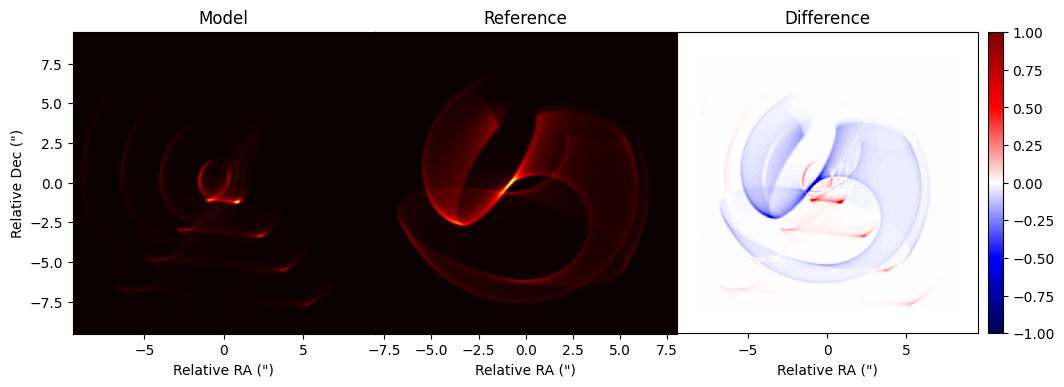

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

resolution = 600    # how many pixels we want on one side of the models
reference_sys = wrb.apep.copy()    # compare to Apep

# now let's generate the reference 'data'. 
particles, weights = gm.dust_plume(reference_sys)   
pixel_bins = jnp.linspace(-8, 8, resolution+1) # -8 to 8 arcsec, +1 on the resolution because these are the coords of the pixel *borders*
ref_X, ref_Y, ref_H = gm.smooth_histogram2d_w_bins(particles, weights, reference_sys, pixel_bins, pixel_bins)

# finally, we can see how four shells of WR140 stack up to one shell of Apep in the GUI
xm.gui.create_GUI(system='WR140', shells=4, resolution=600, reference=[ref_X, ref_Y, ref_H])


Running the above gives us a GUI window that looks like

<img src="assets/gui-custom.png" alt="GUI custom" width="600"/>

In the above example we generated fake 'data' for the reference image, but you can input real observations into the GUI provided that it's in the appropriate format: a list of three arrays, where the first two arrays are your X and Y coordinates for each pixel, and the third array is a 2D array of each pixel value.